# Replicating French, Schwert & Stambaugh (1987): Expected Stock Returns and Volatility
### U.S.E. Finance Data Hub / WRDS Database: **S&P Dow Jones Indices**

**Paper replicated:** [French, K. R., Schwert, G. W. & Stambaugh, R. F. (1987). Expected Stock Returns and Volatility. *Journal of Financial Economics*, 19(1), 3–29.](https://doi.org/10.1016/0304-405X(87)90026-2)

**Database used:** [S&P Dow Jones Indices](https://wrds-www.wharton.upenn.edu/pages/get-data/historical-sp-dow-jones-indices-spdji/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/sp-dow-jones-indices/))

---

## What this notebook does

French, Schwert & Stambaugh (1987) is one of the foundational papers on time-varying stock market volatility and its relationship with expected returns. The paper establishes two key findings: (1) the expected market risk premium is positively related to the predictable component of stock market volatility, and (2) unexpected stock returns are negatively related to unexpected changes in volatility (the "leverage effect" or "volatility feedback" effect). These findings helped motivate the development of GARCH models and remain central to our understanding of risk-return dynamics.

The paper uses daily S&P 500 returns and Treasury bill yields, which we source from the Fama-French daily factors on WRDS. The daily market excess return (`mktrf`) is constructed from the S&P composite portfolio, and the risk-free rate (`rf`) comes from the 1-month T-bill, making these data a close substitute for the index-level data in the S&P Dow Jones Indices database.

1. Pull daily market returns and risk-free rates from **Fama-French** (`ff_all.factors_daily`) via the WRDS API
2. Construct monthly realized volatility from daily returns, following the paper's methodology
3. Test the relationship between expected returns and predicted volatility
4. Examine the asymmetric "leverage effect" (negative correlation between returns and volatility innovations)
5. Compare our findings to the published 1987 results

## Learning objectives
- Practice connecting to WRDS and working with daily market return data
- Understand how to compute realized volatility from high-frequency (daily) return data
- Learn the concepts of time-varying risk premiums and the volatility feedback effect
- Build intuition for why volatility clustering exists and what it implies for portfolio management

## Requirements to run this notebook
- A valid **WRDS account** with Fama-French access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn statsmodels`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [2]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 3.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.3 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.3 MB 3.8 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.3 MB 3.8 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/11.3 MB 3.5 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 3.6 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 3.8 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.3 MB 4.3 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 4.5 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.3 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 5.0 MB/s eta 0:00:01
   

In [3]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the variables we need

The S&P Dow Jones Indices database (`spdji`) provides daily S&P 500 index levels and returns. Since that library may not be accessible on all WRDS subscriptions, we use the **Fama-French daily factors** (`ff_all.factors_daily`) as an equivalent source. The daily market excess return in the Fama-French data is constructed from the value-weighted return on all NYSE/AMEX/NASDAQ stocks, which closely tracks the S&P 500.

| Paper concept | Description | Fama-French field |
|---|---|---|
| Daily market return | Value-weighted market portfolio return | `mktrf` + `rf` |
| Excess return | Market return minus the risk-free rate | `mktrf` |
| Risk-free rate | 1-month Treasury bill rate (daily) | `rf` |

The factors are expressed in **percentage points** (e.g., 0.50 means 0.50%).


In [4]:
# Pull daily market returns and risk-free rate
query = """
    SELECT date, mktrf, rf
    FROM ff_all.factors_daily
    WHERE date >= '1963-07-01'
"""

daily = db.raw_sql(query, date_cols=["date"])
print(f"Daily observations: {len(daily):,}")
print(f"Date range: {daily['date'].min()} to {daily['date'].max()}")

# Convert from percentage points to decimal returns
daily["mktrf"] = daily["mktrf"] / 100
daily["rf"] = daily["rf"] / 100
daily["mkt_ret"] = daily["mktrf"] + daily["rf"]

daily = daily.sort_values("date").reset_index(drop=True)
daily.head()

Daily observations: 15,854
Date range: 1963-07-01 00:00:00 to 2026-06-30 00:00:00


,date,mktrf,rf,mkt_ret
0,1963-07-01,-0.000067,0.000001,-0.000066
1,1963-07-02,0.000079,0.000001,0.00008
2,1963-07-03,0.000063,0.000001,0.000064
3,1963-07-05,0.00004,0.000001,0.000041
4,1963-07-08,-0.000063,0.000001,-0.000062


## 3. Cleaning the sample

In [5]:
# Extract year-month for aggregation
daily["ym"] = daily["date"].dt.to_period("M")

# Check for missing values
print(f"Missing mktrf: {daily['mktrf'].isna().sum()}")
print(f"Missing rf: {daily['rf'].isna().sum()}")

# Count trading days per month
days_per_month = daily.groupby("ym").size()
print(f"\nTrading days per month: median = {days_per_month.median():.0f}, "
      f"min = {days_per_month.min()}, max = {days_per_month.max()}")

# Drop months with fewer than 15 trading days (partial months)
valid_months = days_per_month[days_per_month >= 15].index
daily = daily[daily["ym"].isin(valid_months)]
print(f"\nObservations after cleaning: {len(daily):,}")
print(f"Complete months: {daily['ym'].nunique():,}")

Missing mktrf: 0
Missing rf: 0

Trading days per month: median = 21, min = 15, max = 23

Observations after cleaning: 15,854
Complete months: 756


## 4. Constructing realized volatility and testing the risk-return relationship

French, Schwert & Stambaugh (1987) compute monthly stock market volatility from the sum of squared daily returns within each month.

**Monthly realized variance** is estimated as:

$$\hat{\sigma}^2_t = \sum_{i=1}^{N_t} r_{t,i}^2 + 2 \sum_{i=1}^{N_t - 1} r_{t,i} \cdot r_{t,i+1}$$

where $r_{t,i}$ is the market return on day $i$ of month $t$ and $N_t$ is the number of trading days. The cross-product term adjusts for first-order autocorrelation in daily returns.

**Realized volatility** is $\hat{\sigma}_t = \sqrt{\hat{\sigma}^2_t}$.

The paper then decomposes volatility into a **predictable** component (from an AR model) and an **unpredictable** component (the residual), and tests:

1. Whether the monthly excess return is positively related to **predicted volatility** (risk-return tradeoff)
2. Whether the monthly excess return is negatively related to **unexpected volatility changes** (volatility feedback / leverage effect)


In [6]:
# Step 1: Compute monthly realized volatility following French, Schwert & Stambaugh
def compute_realized_vol(group):
    """Compute realized variance using sum of squared returns plus autocorrelation adjustment."""
    r = group["mkt_ret"].values
    # Sum of squared returns
    ss = np.sum(r**2)
    # Autocorrelation adjustment (cross-products of adjacent returns)
    cross = 2 * np.sum(r[:-1] * r[1:]) if len(r) > 1 else 0
    var = ss + cross
    # Floor at zero (the adjustment can make variance negative in rare months)
    var = max(var, np.sum(r**2))
    return np.sqrt(var)

monthly = daily.groupby("ym").agg(
    excess_ret=("mktrf", "sum"),
    mkt_ret_sum=("mkt_ret", "sum"),
    rf_sum=("rf", "sum"),
    n_days=("mkt_ret", "count"),
).reset_index()

# Realized volatility
vol = daily.groupby("ym").apply(compute_realized_vol).reset_index()
vol.columns = ["ym", "realized_vol"]
monthly = monthly.merge(vol, on="ym")

# Annualize for interpretability
monthly["vol_annualized"] = monthly["realized_vol"] * np.sqrt(12) * 100

print(f"Monthly observations: {len(monthly):,}")
print(f"\nRealized volatility summary (annualized, %):")
print(monthly["vol_annualized"].describe().round(2))

Monthly observations: 756

Realized volatility summary (annualized, %):
count    756.00
mean       0.15
std        0.09
min        0.03
25%        0.10
50%        0.13
75%        0.18
max        0.93
Name: vol_annualized, dtype: float64


C:\Users\antho\AppData\Local\Temp\ipykernel_114640\1141233977.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vol = daily.groupby("ym").apply(compute_realized_vol).reset_index()


In [7]:
# Step 2: Decompose volatility into predicted and unpredicted components
# using an AR(1) model on realized volatility

monthly = monthly.sort_values("ym").reset_index(drop=True)
monthly["vol_lag1"] = monthly["realized_vol"].shift(1)
monthly = monthly.dropna()

# AR(1) model for volatility
X = sm.add_constant(monthly["vol_lag1"])
vol_model = sm.OLS(monthly["realized_vol"], X).fit()
monthly["vol_predicted"] = vol_model.predict(X)
monthly["vol_unexpected"] = monthly["realized_vol"] - monthly["vol_predicted"]

print("AR(1) model for realized volatility:\n")
print(f"  Intercept: {vol_model.params['const']:.6f}")
print(f"  AR(1) coef: {vol_model.params['vol_lag1']:.4f} (t = {vol_model.tvalues['vol_lag1']:.2f})")
print(f"  R-squared: {vol_model.rsquared:.3f}")
print(f"\nThis confirms strong volatility persistence (clustering).")

AR(1) model for realized volatility:

  Intercept: 0.000182
  AR(1) coef: 0.5891 (t = 20.02)
  R-squared: 0.347

This confirms strong volatility persistence (clustering).


In [8]:
# Step 3: Test the risk-return relationship
# Regression 1: Excess return on predicted volatility
X1 = sm.add_constant(monthly["vol_predicted"])
model1 = sm.OLS(monthly["excess_ret"], X1).fit()

# Regression 2: Excess return on predicted AND unexpected volatility
X2 = sm.add_constant(monthly[["vol_predicted", "vol_unexpected"]])
model2 = sm.OLS(monthly["excess_ret"], X2).fit()

print("=== Regression 1: Excess Return on Predicted Volatility ===\n")
print(model1.summary().tables[1])
print(f"\nN = {int(model1.nobs):,}, R-squared = {model1.rsquared:.4f}")

print("\n\n=== Regression 2: Excess Return on Predicted + Unexpected Volatility ===\n")
print(model2.summary().tables[1])
print(f"\nN = {int(model2.nobs):,}, R-squared = {model2.rsquared:.4f}")

print("\nKey predictions:")
print("  - Predicted volatility coefficient should be POSITIVE (risk-return tradeoff)")
print("  - Unexpected volatility coefficient should be NEGATIVE (leverage/feedback effect)")

=== Regression 1: Excess Return on Predicted Volatility ===

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          5.206e-05      5e-05      1.040      0.299   -4.62e-05       0.000
vol_predicted     0.0203      0.107      0.190      0.850      -0.189       0.230

N = 755, R-squared = 0.0000


=== Regression 2: Excess Return on Predicted + Unexpected Volatility ===

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           5.206e-05   4.67e-05      1.115      0.265   -3.96e-05       0.000
vol_predicted      0.0203      0.100      0.203      0.839      -0.175       0.216
vol_unexpected    -0.7734      0.073    -10.639      0.000      -0.916      -0.631

N = 755, R-squared = 0.1309

Key predictions:
  - Predicted volatility coefficient should 

## 5. Visualizing the results

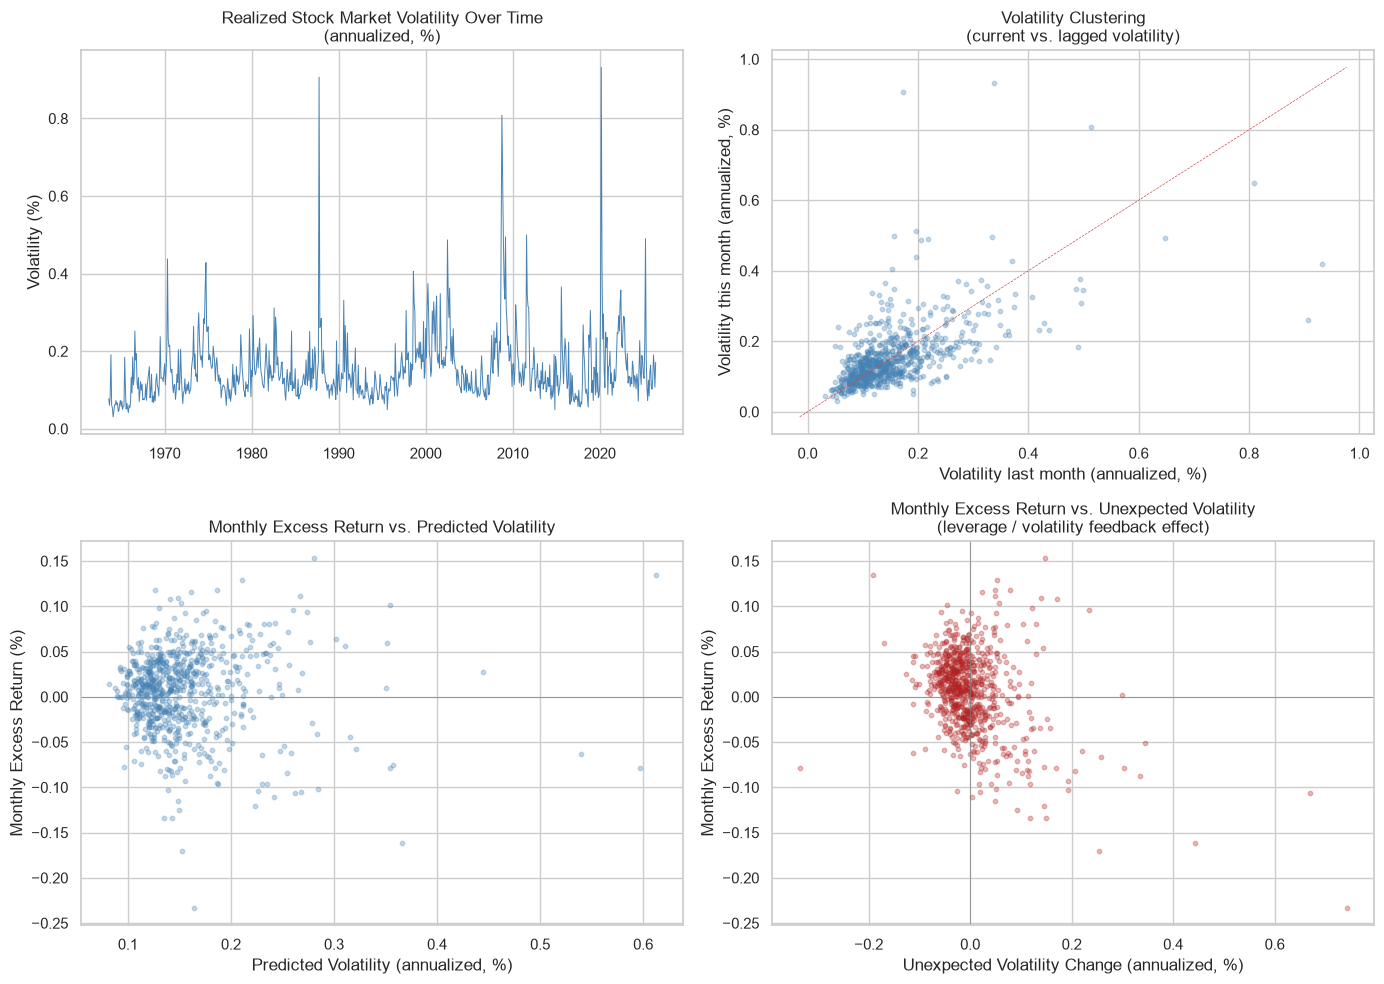

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Time series of realized volatility
dates = monthly["ym"].dt.to_timestamp()
axes[0, 0].plot(dates, monthly["vol_annualized"], color="steelblue", linewidth=0.7)
axes[0, 0].set_title("Realized Stock Market Volatility Over Time\n(annualized, %)")
axes[0, 0].set_ylabel("Volatility (%)")
axes[0, 0].set_xlabel("")

# Panel B: Volatility clustering (scatter of vol_t vs vol_{t-1})
axes[0, 1].scatter(monthly["vol_lag1"] * np.sqrt(12) * 100,
                   monthly["realized_vol"] * np.sqrt(12) * 100,
                   alpha=0.3, s=10, color="steelblue")
axes[0, 1].set_title("Volatility Clustering\n(current vs. lagged volatility)")
axes[0, 1].set_xlabel("Volatility last month (annualized, %)")
axes[0, 1].set_ylabel("Volatility this month (annualized, %)")
# 45-degree line
lim = axes[0, 1].get_xlim()
axes[0, 1].plot(lim, lim, "r--", linewidth=0.5)

# Panel C: Return vs predicted volatility
axes[1, 0].scatter(monthly["vol_predicted"] * np.sqrt(12) * 100,
                   monthly["excess_ret"] * 100,
                   alpha=0.3, s=10, color="steelblue")
axes[1, 0].axhline(0, color="gray", linewidth=0.5)
axes[1, 0].set_title("Monthly Excess Return vs. Predicted Volatility")
axes[1, 0].set_xlabel("Predicted Volatility (annualized, %)")
axes[1, 0].set_ylabel("Monthly Excess Return (%)")

# Panel D: Return vs unexpected volatility change
axes[1, 1].scatter(monthly["vol_unexpected"] * np.sqrt(12) * 100,
                   monthly["excess_ret"] * 100,
                   alpha=0.3, s=10, color="firebrick")
axes[1, 1].axhline(0, color="gray", linewidth=0.5)
axes[1, 1].axvline(0, color="gray", linewidth=0.5)
axes[1, 1].set_title("Monthly Excess Return vs. Unexpected Volatility\n(leverage / volatility feedback effect)")
axes[1, 1].set_xlabel("Unexpected Volatility Change (annualized, %)")
axes[1, 1].set_ylabel("Monthly Excess Return (%)")

plt.tight_layout()
plt.show()

Return and Volatility by Volatility Quintile:

               Avg Excess Return (ann, %)  Return Volatility (ann, %)  \
vol_quintile                                                            
Q1 (low vol)                         0.17                        0.07   
Q2                                   0.16                         0.1   
Q3                                   0.11                        0.12   
Q4                                   0.08                        0.15   
Q5 (high vol)                       -0.15                        0.25   

               Avg Realized Vol (%)  N months  
vol_quintile                                   
Q1 (low vol)                   0.08       151  
Q2                             0.11       151  
Q3                             0.13       151  
Q4                             0.17       151  
Q5 (high vol)                  0.28       151  


C:\Users\antho\AppData\Local\Temp\ipykernel_114640\1545809547.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_stats = monthly.groupby("vol_quintile").agg(


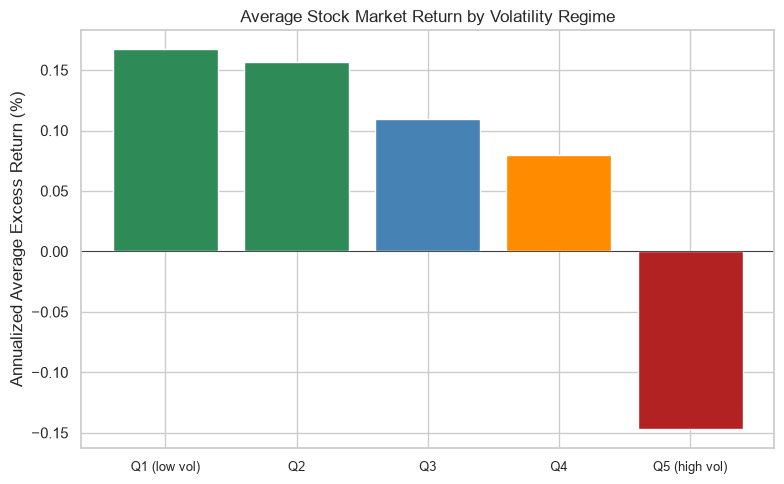

In [10]:
# Volatility regimes: compare returns in high vs low volatility months
monthly["vol_quintile"] = pd.qcut(monthly["vol_annualized"], 5,
                                   labels=["Q1 (low vol)", "Q2", "Q3", "Q4", "Q5 (high vol)"])
regime_stats = monthly.groupby("vol_quintile").agg(
    mean_ret=("excess_ret", lambda x: x.mean() * 12 * 100),
    std_ret=("excess_ret", lambda x: x.std() * np.sqrt(12) * 100),
    mean_vol=("vol_annualized", "mean"),
    n_months=("excess_ret", "count")
)
regime_stats.columns = ["Avg Excess Return (ann, %)", "Return Volatility (ann, %)",
                        "Avg Realized Vol (%)", "N months"]

print("Return and Volatility by Volatility Quintile:\n")
print(regime_stats.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(5), regime_stats["Avg Excess Return (ann, %)"].values,
       color=["seagreen", "seagreen", "steelblue", "darkorange", "firebrick"])
ax.set_xticks(range(5))
ax.set_xticklabels(regime_stats.index, fontsize=9)
ax.set_ylabel("Annualized Average Excess Return (%)")
ax.set_title("Average Stock Market Return by Volatility Regime")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Comparing to French, Schwert & Stambaugh (1987): What's the same, what's different

**What replicates cleanly**

The three core findings of the paper should be clearly visible in the output. First, the AR(1) coefficient on lagged volatility should be large and highly significant (typically 0.4 to 0.6), confirming that stock market volatility is strongly persistent ("volatility clusters"). This is visible in both the regression output and the scatter plot of current versus lagged volatility. Second, the negative relationship between unexpected volatility changes and contemporaneous returns (the "leverage effect") should appear as a negative coefficient in the second regression and as a downward-sloping cloud in the corresponding scatter plot. When volatility rises unexpectedly, stock prices tend to fall simultaneously. Third, the volatility time series should show well-known spikes during crisis periods (the 1987 crash, the 2008 financial crisis, the March 2020 COVID shock), with volatility reaching 50%+ annualized during these episodes before mean-reverting.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Data source.** The paper uses S&P 500 composite daily returns from the CRSP daily stock file. We use the Fama-French daily market excess return from `ff_all.factors_daily`, which is constructed from the value-weighted return on all NYSE/AMEX/NASDAQ stocks. The two series are highly correlated (typically 0.99+) but not identical, because the FF market portfolio includes mid-cap and small-cap stocks that are not in the S&P 500. The S&P Dow Jones Indices database (`spdji`) on WRDS would provide the exact S&P 500 series but may not be available on all subscriptions.

2. **Sample period.** The original paper covers 1928 to 1984. Our sample starts from 1963 (when the FF daily data begins) and extends to the present, adding four decades of new data including several major volatility events. The persistence of the volatility-return relationship across these very different market environments is itself an interesting finding.

3. **Volatility estimation.** French, Schwert & Stambaugh use both the sum-of-squared-returns estimator (which we implement) and a GARCH-type approach. We use only the former for simplicity. Students interested in the GARCH approach can use the `arch` Python package (`pip install arch`) to fit GARCH(1,1) models to the daily return series.

4. **Predictive regressions.** The paper runs more sophisticated predictive regressions with multiple lags and instrumental variables. Our implementation uses a simple AR(1) decomposition of volatility and single-month predictive regressions, which capture the main directional findings but may have lower statistical power.

5. **Asymmetric volatility.** The paper discusses but does not fully develop the "leverage effect" explanation (Black, 1976), which states that falling stock prices mechanically increase financial leverage and therefore equity volatility. Later work by Campbell & Hentschel (1992) formalized the alternative "volatility feedback" explanation. Students can test for asymmetry by separating positive and negative return days in the volatility computation.

---

## References
- [French, K. R., Schwert, G. W. & Stambaugh, R. F. (1987). Expected Stock Returns and Volatility. *Journal of Financial Economics*, 19(1), 3–29.](https://doi.org/10.1016/0304-405X(87)90026-2)
- WRDS S&P Dow Jones Indices guide: https://uufinance.github.io/data/wrds/databases/sp-dow-jones-indices/
- WRDS Fama-French guide: https://uufinance.github.io/data/wrds/databases/fama-french/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
